In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib widget

In [2]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    return np.dot(rotation_matrix, z)


# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, s_k,
                     r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a):

    theta3 = theta_init[0]
    theta4 = theta_init[1]
    theta5 = theta_init[2]
    theta6 = theta_init[3]
    theta7 = theta_init[4]
    theta8 = theta_init[5]

    # loop 1
    F1 = (r3a + r3b) * np.cos(theta3) - r4a * np.cos(theta4)
    F2 = -s_k + (r3a + r3b) * np.sin(theta3) - r4a * np.sin(theta4)

    # loop 2
    F3 = -r3b * np.cos(theta3) + (r5a + r5b) * np.cos(theta5) + r7a * np.cos(theta7) - r4b * np.cos(theta4)
    F4 = -r3b * np.sin(theta3) + (r5a + r5b) * np.sin(theta5) + r7a * np.sin(theta7) - r4b * np.sin(theta4)

    # loop 3
    F5 = -r5b * np.cos(theta5) + r6 * np.cos(theta6) + r8a * np.cos(theta8) - (r7a + r7b) * np.cos(theta7)
    F6 = -r5b * np.sin(theta5) + r6 * np.sin(theta6) + r8a * np.sin(theta8) - (r7a + r7b) * np.sin(theta7)

    return [F1, F2, F3, F4, F5, F6]


def compute_A_matrix(theta, r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a):
    theta3, theta4, theta5, theta6, theta7, theta8 = theta

    A = np.array([
        [-(r3a + r3b) * np.sin(theta3),  r4a * np.sin(theta4), 0, 0, 0, 0],
        [ (r3a + r3b) * np.cos(theta3), -r4a * np.cos(theta4), 0, 0, 0, 0],

        [ r3b * np.sin(theta3),          r4b * np.sin(theta4), -(r5a + r5b) * np.sin(theta5), 0, -r7a * np.sin(theta7), 0],
        [-r3b * np.cos(theta3),         -r4b * np.cos(theta4),  (r5a + r5b) * np.cos(theta5), 0,  r7a * np.cos(theta7), 0],

        [0, 0,  r5b * np.sin(theta5), -r6 * np.sin(theta6),  (r7a + r7b) * np.sin(theta7), -r8a * np.sin(theta8)],
        [0, 0, -r5b * np.cos(theta5),  r6 * np.cos(theta6), -(r7a + r7b) * np.cos(theta7),  r8a * np.cos(theta8)]
    ])

    return A


def solve_theta_for_s(s_val, theta_guess,
                      r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a,
                      xtol=1e-10, maxfev=2000):

    x, infodict, ier, message = fsolve(
        lambda x: loop_closure_eqs(
            x, s_val,
            r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
        ),
        theta_guess,
        full_output=True,
        xtol=xtol,
        maxfev=maxfev
    )

    residual = np.linalg.norm(loop_closure_eqs(
        x, s_val,
        r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
    ))

    success = (ier == 1) and (residual < 1e-7)

    if success:
        A = compute_A_matrix(x, r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a)
        condA = np.linalg.cond(A)
    else:
        condA = np.inf

    return success, x, residual, condA, message


def continue_solution_in_s(s_from, s_to, theta_from,
                           r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a,
                           ds_step=0.002):
    """
    Continue a known valid configuration from s_from to s_to
    using small steps and previous solution as initial guess.
    """
    theta_current = np.array(theta_from, dtype=float)

    if s_to == s_from:
        return True, theta_current, s_from, 0.0, 0.0, "already at target"

    direction = np.sign(s_to - s_from)
    s_current = s_from

    while abs(s_to - s_current) > ds_step:
        s_next = s_current + direction * ds_step

        ok, theta_next, residual, condA, message = solve_theta_for_s(
            s_next, theta_current,
            r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
        )

        if not ok:
            return False, theta_current, s_current, residual, condA, message

        s_current = s_next
        theta_current = theta_next

    ok, theta_target, residual, condA, message = solve_theta_for_s(
        s_to, theta_current,
        r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
    )

    if not ok:
        return False, theta_current, s_current, residual, condA, message

    return True, theta_target, s_to, residual, condA, message


def scan_s_range(s_start, theta_start,
                 r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a,
                 ds_scan=0.001, n_steps=400, cond_limit=1e4):
    # scan upward: smaller s, toward C
    s_up = [s_start]
    theta_up = [np.array(theta_start)]
    cond_up = []
    resid_up = []

    theta_guess = np.array(theta_start)

    for i in range(n_steps):
        s_try = s_up[-1] - ds_scan
        ok, x, res, condA, msg = solve_theta_for_s(
            s_try, theta_guess,
            r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
        )
        if not ok:
            break
        s_up.append(s_try)
        theta_up.append(x)
        cond_up.append(condA)
        resid_up.append(res)
        theta_guess = x

    # scan downward: larger s, away from C
    s_down = [s_start]
    theta_down = [np.array(theta_start)]
    cond_down = []
    resid_down = []

    theta_guess = np.array(theta_start)

    for i in range(n_steps):
        s_try = s_down[-1] + ds_scan
        ok, x, res, condA, msg = solve_theta_for_s(
            s_try, theta_guess,
            r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
        )
        if not ok:
            break
        s_down.append(s_try)
        theta_down.append(x)
        cond_down.append(condA)
        resid_down.append(res)
        theta_guess = x

    s_min_math = np.min(s_up)
    s_max_math = np.max(s_down)

    s_min_safe = s_start
    for i, c in enumerate(cond_up, start=1):
        if c > cond_limit:
            break
        s_min_safe = s_up[i]

    s_max_safe = s_start
    for i, c in enumerate(cond_down, start=1):
        if c > cond_limit:
            break
        s_max_safe = s_down[i]

    return {
        "s_up": np.array(s_up),
        "s_down": np.array(s_down),
        "theta_up": theta_up,
        "theta_down": theta_down,
        "cond_up": np.array(cond_up),
        "cond_down": np.array(cond_down),
        "resid_up": np.array(resid_up),
        "resid_down": np.array(resid_down),
        "s_min_math": s_min_math,
        "s_max_math": s_max_math,
        "s_min_safe": s_min_safe,
        "s_max_safe": s_max_safe
    }

In [3]:
def unpack_params(params):
    return (
        params["r3a"], params["r3b"], params["r4a"], params["r4b"],
        params["r5a"], params["r5b"], params["r6"], params["r7a"],
        params["r7b"], params["r8a"], params["r8b"]
    )


def compute_points_from_state(s_val, theta, params):
    r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a, r8b = unpack_params(params)
    theta3, theta4, theta5, theta6, theta7, theta8 = theta

    C = np.array([0.0, 0.0])
    B = C + np.array([0.0, -s_val])

    D = B + rotate_vector(np.array([r3a, 0.0]), theta3)
    E = D + rotate_vector(np.array([r3b, 0.0]), theta3)

    E_from_4 = C + rotate_vector(np.array([r4a, 0.0]), theta4)
    H = E_from_4 + rotate_vector(np.array([r4b, 0.0]), theta4)

    F = D + rotate_vector(np.array([r5a, 0.0]), theta5)
    G = F + rotate_vector(np.array([r5b, 0.0]), theta5)

    I = F + rotate_vector(np.array([r6, 0.0]), theta6)
    J = I + rotate_vector(np.array([r8a, 0.0]), theta8)
    K = J + rotate_vector(np.array([r8b, 0.0]), theta8)

    return {
        "C": C, "B": B, "D": D, "E": E, "E_from_4": E_from_4, "F": F,
        "G": G, "H": H, "I": I, "J": J, "K": K
    }


def basic_geometry_check(params):
    vals = np.array(list(params.values()))
    if np.any(vals <= 0):
        return False

    if params["r8b"] <= params["r8a"]:
        return False

    if params["r4a"] <= params["r3b"]:
        return False

    return True


def sample_random_params(rng, bounds):
    return {name: rng.uniform(low, high) for name, (low, high) in bounds.items()}

In [4]:
def complete_params(params):
    params = params.copy()
    params["r8a"] = params["r5b"]
    params["r4b"] = params["r5a"] + params["r5b"]
    params["r6"] = params["r7a"] + params["r7b"]
    params["r3b"] = params["r7a"]
    return params

In [5]:
def evaluate_candidate(params,
                       s_open,
                       s_closed,
                       theta_closed_guess,
                       L1,
                       cond_limit=2e3,
                       continuation_step=0.002):
    
    params = complete_params(params)

    if not basic_geometry_check(params):
        return {"success": False, "score": 1e12, "reason": "basic geometry check failed"}

    r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a, r8b = unpack_params(params)

    # 1) eerst gesloten configuratie vinden bij s_closed
    ok_closed, theta_closed, residual_closed, cond_closed, msg_closed = solve_theta_for_s(
        s_closed, theta_closed_guess,
        r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
    )

    if not ok_closed:
        return {
            "success": False,
            "score": 1e11,
            "reason": f"no closed configuration at s_closed={s_closed:.4f}"
        }

    # 2) continuation van gesloten naar open
    ok_open, theta_open, s_reached, residual_open, cond_open, msg_open = continue_solution_in_s(
        s_from=s_closed,
        s_to=s_open,
        theta_from=theta_closed,
        r3a=r3a, r3b=r3b, r4a=r4a, r4b=r4b,
        r5a=r5a, r5b=r5b, r6=r6, r7a=r7a, r7b=r7b, r8a=r8a,
        ds_step=continuation_step
    )

    if not ok_open:
        return {
            "success": False,
            "score": 1e10,
            "reason": f"continuation failed near s={s_reached:.4f}"
        }

    # 3) scan hele range voor conditionering
    scan = scan_s_range(
        s_start=s_closed,
        theta_start=theta_closed,
        r3a=r3a, r3b=r3b, r4a=r4a, r4b=r4b,
        r5a=r5a, r5b=r5b, r6=r6, r7a=r7a, r7b=r7b, r8a=r8a,
        ds_scan=0.002,
        n_steps=int(np.ceil((s_closed - s_open)/0.002)) + 20,
        cond_limit=cond_limit
    )

    if scan["s_min_safe"] > s_open + 1e-6:
        return {
            "success": False,
            "score": 1e9,
            "reason": "safe range does not reach open position"
        }

    pts_closed = compute_points_from_state(s_closed, theta_closed, params)
    pts_open   = compute_points_from_state(s_open, theta_open, params)

    K_closed = pts_closed["K"]
    K_open   = pts_open["K"]


    # open rib moet ongeveer naar rechts-boven wijzen
    theta8_open = theta_open[5]
    desired_theta8 = 0.45
    rib_penalty = 20.0 * (theta8_open - desired_theta8)**2

    

    # conditionering
    cond_candidates = [cond_closed, cond_open]
    if len(scan["cond_up"]) > 0:
        cond_candidates.append(np.max(scan["cond_up"]))
    if len(scan["cond_down"]) > 0:
        cond_candidates.append(np.max(scan["cond_down"]))
    

    # gesloten stand: K relatief dicht bij mast en laag
    closed_penalty = 0.0
    # open stand: K duidelijk naar rechts en hoger
    open_penalty = 0.0
    
    closed_penalty += 500.0 * max(0.0, K_closed[0] - 0.05 * L1)**2
    closed_penalty += 250.0 * max(0.0, K_closed[1] + 0.02 * L1)**2

    open_penalty += 200.0 * max(0.0, 0.35 * L1 - K_open[0])**2
    open_penalty += 130.0 * max(0.0, -K_open[1] - 0.10 * L1)**2

    motion_penalty = 150.0 * max(0.0, 0.18 * L1 - (K_open[0] - K_closed[0]))**2

    cond_penalty = 0.25 * max(cond_candidates)

    score = closed_penalty + open_penalty + rib_penalty + motion_penalty + cond_penalty

    return {
        "success": True,
        "score": score,
        "reason": "ok",
        "params": params,
        "theta_closed": theta_closed,
        "theta_open": theta_open,
        "K_closed": K_closed,
        "K_open": K_open,
        "cond_closed": cond_closed,
        "cond_open": cond_open,
        "scan": scan
    }

In [6]:
def random_search_best(n_samples,
                       bounds,
                       s_open,
                       s_closed,
                       theta_closed_guess,
                       L1,
                       seed=42):

    rng = np.random.default_rng(seed)

    best = None
    history = []

    for k in range(n_samples):
        params = sample_random_params(rng, bounds)
        report = evaluate_candidate(
            params=params,
            s_open=s_open,
            s_closed=s_closed,
            theta_closed_guess=theta_closed_guess,
            L1=L1
        )

        history.append(report)

        if report["success"]:
            if (best is None) or (report["score"] < best["score"]):
                best = report.copy()

    return best, history

In [7]:
# ============================================
# ONTWERPINPUTS
# ============================================

L1 = 2.5   # mast length [m]

# klein s = open, groot s = gesloten
s_open_target   = 0.05 * L1
s_closed_target = 0.75 * L1

# gesloten stand als initiële gok
theta_closed_guess = np.array([
    0.20,   # theta3
    1.15,   # theta4
   -0.95,   # theta5
    0.20,   # theta6
    1.20,   # theta7
   -0.70    # theta8
])

bounds = {
    "r3a": (0.18 * L1, 0.38 * L1),
    "r4a": (0.252 * L1, 0.452 * L1),
    "r5a": (0.10 * L1, 0.30 * L1),
    "r5b": (0 * L1, 0.172 * L1),
    "r7a": (0 * L1, 0.172 * L1),
    "r7b": (0.10 * L1, 0.30 * L1),
    "r8b": (0.148 * L1, 0.348 * L1),
}

In [8]:
best_report, history = random_search_best(
    n_samples=5000,
    bounds=bounds,
    s_open=s_open_target,
    s_closed=s_closed_target,
    theta_closed_guess=theta_closed_guess,
    L1=L1,
    seed=42
)

if best_report is None:
    raise RuntimeError("Geen bruikbare parameter-set gevonden. Vergroot bounds of n_samples.")

print("Beste score:", best_report["score"])
print("K_closed =", best_report["K_closed"])
print("K_open   =", best_report["K_open"])
print("cond_closed =", best_report["cond_closed"])
print("cond_open   =", best_report["cond_open"])

best_params = best_report["params"]
for k, v in best_params.items():
    print(f"{k} = {v:.6f}")

Beste score: 70.84574855057951
K_closed = [ 0.15368744 -1.75976592]
K_open   = [ 2.63102546 -0.57579073]
cond_closed = 58.85936362277714
cond_open   = 92.05907743648574
r3a = 0.760956
r4a = 0.955804
r5a = 0.283160
r5b = 0.307367
r7a = 0.175872
r7b = 0.486856
r8b = 0.662508
r8a = 0.307367
r4b = 0.590527
r6 = 0.662728
r3b = 0.175872


In [9]:
r3a = best_params["r3a"]
r3b = best_params["r3b"]
r4a = best_params["r4a"]
r4b = best_params["r4b"]
r5a = best_params["r5a"]
r5b = best_params["r5b"]
r6  = best_params["r6"]
r7a = best_params["r7a"]
r7b = best_params["r7b"]
r8a = best_params["r8a"]
r8b = best_params["r8b"]

print("Parameters ready for simulation:")
print(f"r3a = {r3a:.6f}")
print(f"r3b = {r3b:.6f}")
print(f"r4a = {r4a:.6f}")
print(f"r4b = {r4b:.6f}")
print(f"r5a = {r5a:.6f}")
print(f"r5b = {r5b:.6f}")
print(f"r6  = {r6:.6f}")
print(f"r7a = {r7a:.6f}")
print(f"r7b = {r7b:.6f}")
print(f"r8a = {r8a:.6f}")
print(f"r8b = {r8b:.6f}")

Parameters ready for simulation:
r3a = 0.760956
r3b = 0.175872
r4a = 0.955804
r4b = 0.590527
r5a = 0.283160
r5b = 0.307367
r6  = 0.662728
r7a = 0.175872
r7b = 0.486856
r8a = 0.307367
r8b = 0.662508


In [10]:
# configuration of numerical simulation interval and sampling:
t_begin = 0.0
t_end   = 12.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

# slider input:
# s is measured downward from C
# start bij gesloten toestand: s(0) = s_upper
s_lower = s_open_target
s_upper = s_closed_target
omega = 0.8
s_mid = 0.5 * (s_lower + s_upper)
A_s   = 0.5 * (s_upper - s_lower)

s   = s_mid + A_s * np.cos(omega * t)
ds  = -omega * A_s * np.sin(omega * t)
dds = -omega**2 * A_s * np.cos(omega * t)

print(f"s[0] = {s[0]:.6f} m (gesloten start)")
print(f"s_lower = {s_lower:.6f} m")
print(f"s_upper = {s_upper:.6f} m")

s[0] = 1.875000 m (gesloten start)
s_lower = 0.125000 m
s_upper = 1.875000 m


In [11]:
theta_closed = best_report["theta_closed"]

theta3_init = theta_closed[0]
theta4_init = theta_closed[1]
theta5_init = theta_closed[2]
theta6_init = theta_closed[3]
theta7_init = theta_closed[4]
theta8_init = theta_closed[5]

print("Initial closed angles:")
print(f"theta3_init = {theta3_init:.6f}")
print(f"theta4_init = {theta4_init:.6f}")
print(f"theta5_init = {theta5_init:.6f}")
print(f"theta6_init = {theta6_init:.6f}")
print(f"theta7_init = {theta7_init:.6f}")
print(f"theta8_init = {theta8_init:.6f}")

Initial closed angles:
theta3_init = 1.432805
theta4_init = -1.435562
theta5_init = -1.211154
theta6_init = -4.079521
theta7_init = -4.079521
theta8_init = -1.211154


In [12]:
theta_start = theta_closed.copy()

result = scan_s_range(
    s_start=s_upper,
    theta_start=theta_start,
    r3a=r3a, r3b=r3b, r4a=r4a, r4b=r4b,
    r5a=r5a, r5b=r5b, r6=r6, r7a=r7a, r7b=r7b, r8a=r8a,
    ds_scan=0.001,
    n_steps=600,
    cond_limit=1e4
)

print("Mathematisch bereik:")
print(f"s_min_math = {result['s_min_math']:.4f} m")
print(f"s_max_math = {result['s_max_math']:.4f} m")

print("\nVeilig bereik (op basis van cond(A) < 1e4):")
print(f"s_min_safe = {result['s_min_safe']:.4f} m")
print(f"s_max_safe = {result['s_max_safe']:.4f} m")

Mathematisch bereik:
s_min_math = 1.2750 m
s_max_math = 1.8920 m

Veilig bereik (op basis van cond(A) < 1e4):
s_min_safe = 1.2750 m
s_max_safe = 1.8920 m


In [13]:
# Function to compute the kinematics of umbrella mechanism:

def kinematics_umbrella(r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a,
                        s, ds, dds,
                        theta3_init, theta4_init, theta5_init, theta6_init, theta7_init, theta8_init,
                        t):

    optim_options = {"full_output": True}  # options for fsolve

    # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):

        # Position Analysis
        x, _, ier, message = fsolve(
            lambda x: loop_closure_eqs(
                x, s[k],
                r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a
            ),
            [theta3_init, theta4_init, theta5_init, theta6_init, theta7_init, theta8_init],
            **optim_options
        )

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta3[k] = x[0]
        theta4[k] = x[1]
        theta5[k] = x[2]
        theta6[k] = x[3]
        theta7[k] = x[4]
        theta8[k] = x[5]

        # velocity closure:
        A = np.array([
            [-(r3a + r3b) * np.sin(theta3[k]),  r4a * np.sin(theta4[k]), 0, 0, 0, 0],
            [ (r3a + r3b) * np.cos(theta3[k]), -r4a * np.cos(theta4[k]), 0, 0, 0, 0],

            [ r3b * np.sin(theta3[k]),          r4b * np.sin(theta4[k]), -(r5a + r5b) * np.sin(theta5[k]), 0, -r7a * np.sin(theta7[k]), 0],
            [-r3b * np.cos(theta3[k]),         -r4b * np.cos(theta4[k]),  (r5a + r5b) * np.cos(theta5[k]), 0,  r7a * np.cos(theta7[k]), 0],

            [0, 0,  r5b * np.sin(theta5[k]), -r6 * np.sin(theta6[k]),  (r7a + r7b) * np.sin(theta7[k]), -r8a * np.sin(theta8[k])],
            [0, 0, -r5b * np.cos(theta5[k]),  r6 * np.cos(theta6[k]), -(r7a + r7b) * np.cos(theta7[k]),  r8a * np.cos(theta8[k])]
        ])

        B = np.array([
            0,
            ds[k],
            0,
            0,
            0,
            0
        ])

        x = np.linalg.solve(A, B)

        dtheta3[k] = x[0]
        dtheta4[k] = x[1]
        dtheta5[k] = x[2]
        dtheta6[k] = x[3]
        dtheta7[k] = x[4]
        dtheta8[k] = x[5]

        cond[k] = np.linalg.cond(A)

        # acceleration closure:
        B = np.array([
            (r3a + r3b) * np.cos(theta3[k]) * dtheta3[k]**2 - r4a * np.cos(theta4[k]) * dtheta4[k]**2,

            dds[k]
            + (r3a + r3b) * np.sin(theta3[k]) * dtheta3[k]**2
            - r4a * np.sin(theta4[k]) * dtheta4[k]**2,

            -r3b * np.cos(theta3[k]) * dtheta3[k]**2
            + (r5a + r5b) * np.cos(theta5[k]) * dtheta5[k]**2
            + r7a * np.cos(theta7[k]) * dtheta7[k]**2
            - r4b * np.cos(theta4[k]) * dtheta4[k]**2,

            -r3b * np.sin(theta3[k]) * dtheta3[k]**2
            + (r5a + r5b) * np.sin(theta5[k]) * dtheta5[k]**2
            + r7a * np.sin(theta7[k]) * dtheta7[k]**2
            - r4b * np.sin(theta4[k]) * dtheta4[k]**2,

            -r5b * np.cos(theta5[k]) * dtheta5[k]**2
            + r6 * np.cos(theta6[k]) * dtheta6[k]**2
            + r8a * np.cos(theta8[k]) * dtheta8[k]**2
            - (r7a + r7b) * np.cos(theta7[k]) * dtheta7[k]**2,

            -r5b * np.sin(theta5[k]) * dtheta5[k]**2
            + r6 * np.sin(theta6[k]) * dtheta6[k]**2
            + r8a * np.sin(theta8[k]) * dtheta8[k]**2
            - (r7a + r7b) * np.sin(theta7[k]) * dtheta7[k]**2
        ])

        x = np.linalg.solve(A, B)

        ddtheta3[k] = x[0]
        ddtheta4[k] = x[1]
        ddtheta5[k] = x[2]
        ddtheta6[k] = x[3]
        ddtheta7[k] = x[4]
        ddtheta8[k] = x[5]

        # Next iteration with initial values from simple integration:
        theta3_init = theta3[k] + (t[1] - t[0]) * dtheta3[k]
        theta4_init = theta4[k] + (t[1] - t[0]) * dtheta4[k]
        theta5_init = theta5[k] + (t[1] - t[0]) * dtheta5[k]
        theta6_init = theta6[k] + (t[1] - t[0]) * dtheta6[k]
        theta7_init = theta7[k] + (t[1] - t[0]) * dtheta7[k]
        theta8_init = theta8[k] + (t[1] - t[0]) * dtheta8[k]

    return theta3, theta4, theta5, theta6, theta7, theta8, \
           dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, dtheta8, \
           ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, ddtheta8, cond

In [14]:
# compute the kinematics at all sample times "t":

t_size = len(t)
sim_fraction = 2
frames = t_size / sim_fraction
delta = int(np.floor(t_size / frames))
index_vec = np.arange(0, t_size, delta)

theta3   = np.zeros_like(t)
theta4   = np.zeros_like(t)
theta5   = np.zeros_like(t)
theta6   = np.zeros_like(t)
theta7   = np.zeros_like(t)
theta8   = np.zeros_like(t)

dtheta3  = np.zeros_like(t)
dtheta4  = np.zeros_like(t)
dtheta5  = np.zeros_like(t)
dtheta6  = np.zeros_like(t)
dtheta7  = np.zeros_like(t)
dtheta8  = np.zeros_like(t)

ddtheta3 = np.zeros_like(t)
ddtheta4 = np.zeros_like(t)
ddtheta5 = np.zeros_like(t)
ddtheta6 = np.zeros_like(t)
ddtheta7 = np.zeros_like(t)
ddtheta8 = np.zeros_like(t)

cond = np.zeros_like(t)

[theta3, theta4, theta5, theta6, theta7, theta8,
 dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, dtheta8,
 ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, ddtheta8, cond] = \
    kinematics_umbrella(
        r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a,
        s, ds, dds,
        theta3_init, theta4_init, theta5_init, theta6_init, theta7_init, theta8_init,
        t
    )

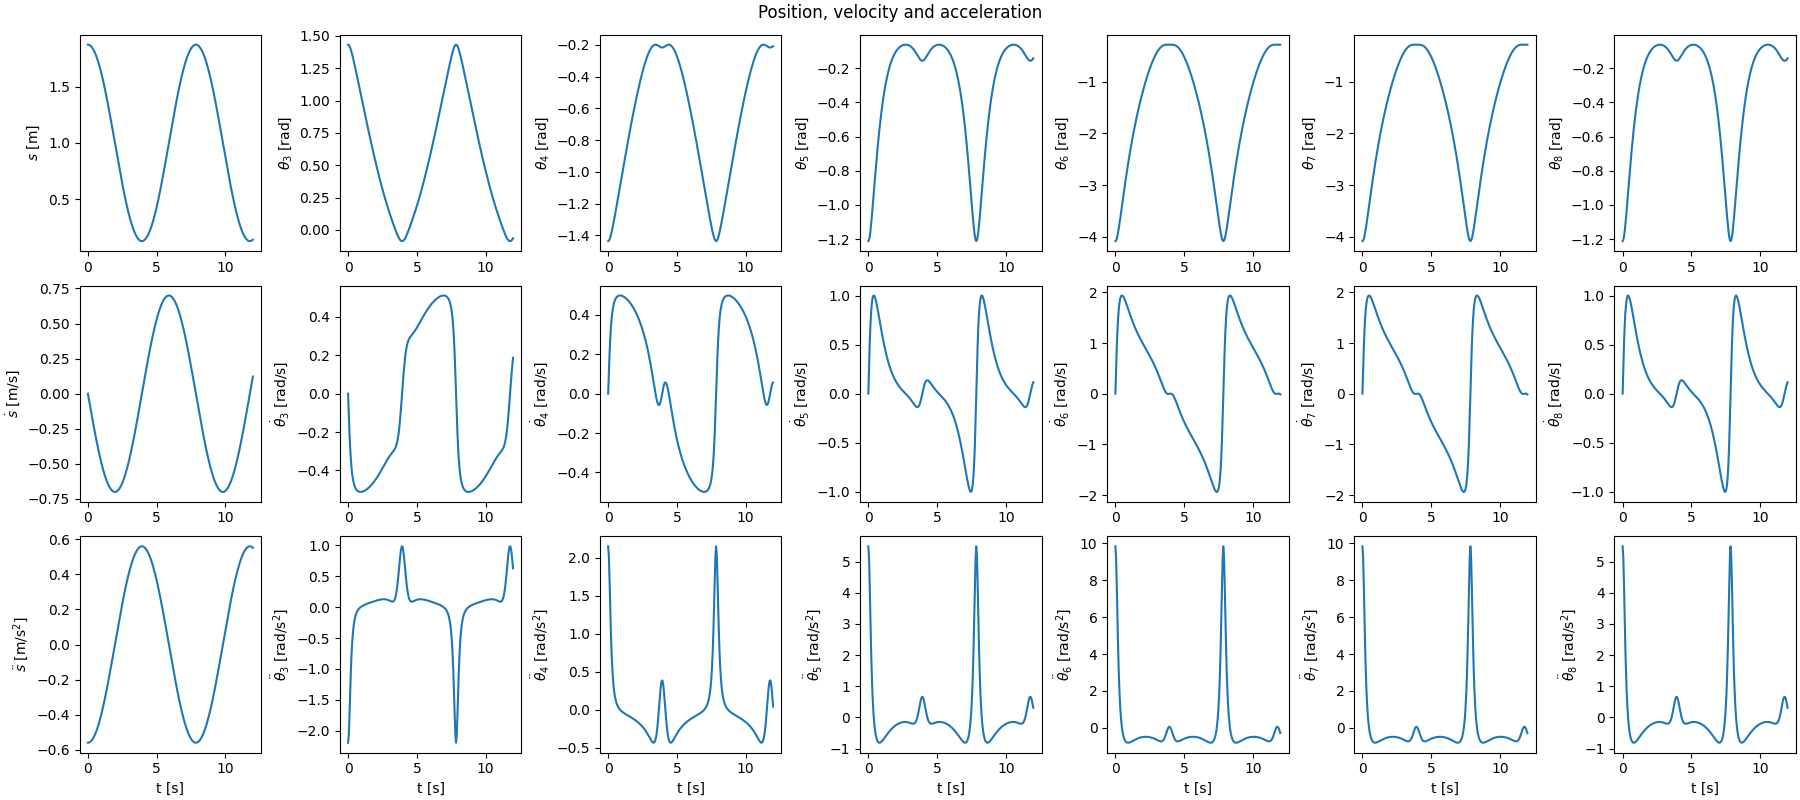

In [15]:
fig1, ax1 = plt.subplots(nrows=3, ncols=7, constrained_layout=True, figsize=(18, 8))
fig1.suptitle("Position, velocity and acceleration")

ax1[0,0].plot(t, s)
ax1[0,0].set_ylabel(r'$s$ [m]')

ax1[0,1].plot(t, theta3)
ax1[0,1].set_ylabel(r'$\theta_3$ [rad]')

ax1[0,2].plot(t, theta4)
ax1[0,2].set_ylabel(r'$\theta_4$ [rad]')

ax1[0,3].plot(t, theta5)
ax1[0,3].set_ylabel(r'$\theta_5$ [rad]')

ax1[0,4].plot(t, theta6)
ax1[0,4].set_ylabel(r'$\theta_6$ [rad]')

ax1[0,5].plot(t, theta7)
ax1[0,5].set_ylabel(r'$\theta_7$ [rad]')

ax1[0,6].plot(t, theta8)
ax1[0,6].set_ylabel(r'$\theta_8$ [rad]')

ax1[1,0].plot(t, ds)
ax1[1,0].set_ylabel(r'$\dot{s}$ [m/s]')

ax1[1,1].plot(t, dtheta3)
ax1[1,1].set_ylabel(r'$\dot{\theta}_3$ [rad/s]')

ax1[1,2].plot(t, dtheta4)
ax1[1,2].set_ylabel(r'$\dot{\theta}_4$ [rad/s]')

ax1[1,3].plot(t, dtheta5)
ax1[1,3].set_ylabel(r'$\dot{\theta}_5$ [rad/s]')

ax1[1,4].plot(t, dtheta6)
ax1[1,4].set_ylabel(r'$\dot{\theta}_6$ [rad/s]')

ax1[1,5].plot(t, dtheta7)
ax1[1,5].set_ylabel(r'$\dot{\theta}_7$ [rad/s]')

ax1[1,6].plot(t, dtheta8)
ax1[1,6].set_ylabel(r'$\dot{\theta}_8$ [rad/s]')

ax1[2,0].plot(t, dds)
ax1[2,0].set_ylabel(r'$\ddot{s}$ [m/s$^2$]')
ax1[2,0].set_xlabel('t [s]')

ax1[2,1].plot(t, ddtheta3)
ax1[2,1].set_ylabel(r'$\ddot{\theta}_3$ [rad/s$^2$]')
ax1[2,1].set_xlabel('t [s]')

ax1[2,2].plot(t, ddtheta4)
ax1[2,2].set_ylabel(r'$\ddot{\theta}_4$ [rad/s$^2$]')
ax1[2,2].set_xlabel('t [s]')

ax1[2,3].plot(t, ddtheta5)
ax1[2,3].set_ylabel(r'$\ddot{\theta}_5$ [rad/s$^2$]')
ax1[2,3].set_xlabel('t [s]')

ax1[2,4].plot(t, ddtheta6)
ax1[2,4].set_ylabel(r'$\ddot{\theta}_6$ [rad/s$^2$]')
ax1[2,4].set_xlabel('t [s]')

ax1[2,5].plot(t, ddtheta7)
ax1[2,5].set_ylabel(r'$\ddot{\theta}_7$ [rad/s$^2$]')
ax1[2,5].set_xlabel('t [s]')

ax1[2,6].plot(t, ddtheta8)
ax1[2,6].set_ylabel(r'$\ddot{\theta}_8$ [rad/s$^2$]')
ax1[2,6].set_xlabel('t [s]')

plt.show()

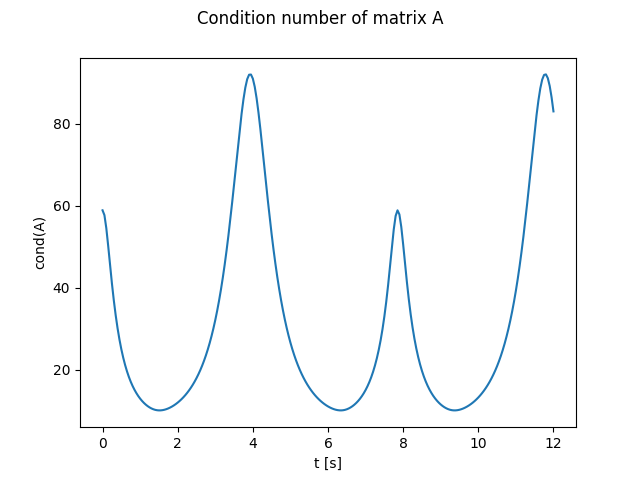

In [16]:
figc, axc = plt.subplots()
figc.suptitle("Condition number of matrix A")

axc.plot(t, cond)
axc.set_ylabel("cond(A)")
axc.set_xlabel("t [s]")
plt.show()

In [17]:
plt.ioff()
fig2, ax = plt.subplots()

C = np.array([0.0, 0.0])

all_lengths = np.array([r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a, r8b])
Lmax = np.sum(all_lengths)

x_left   = -0.10 * L1
x_right  =  1.25 * L1
y_bottom = -1.05 * L1
y_top    = 0.75 * L1

def update(frame):
    global fig2, ax, C, index_vec

    k = index_vec[frame]

    ax.cla()
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Time {t[k]:.2f}')

    C = np.array([0.0, 0.0])
    B = C + np.array([0.0, -s[k]])

    D = B + rotate_vector(np.array([r3a, 0.0]), theta3[k])
    E_from_3 = D + rotate_vector(np.array([r3b, 0.0]), theta3[k])

    E_from_4 = C + rotate_vector(np.array([r4a, 0.0]), theta4[k])
    H = E_from_4 + rotate_vector(np.array([r4b, 0.0]), theta4[k])

    E = 0.5 * (E_from_3 + E_from_4)

    F = D + rotate_vector(np.array([r5a, 0.0]), theta5[k])
    G_from_5 = F + rotate_vector(np.array([r5b, 0.0]), theta5[k])

    I = F + rotate_vector(np.array([r6, 0.0]), theta6[k])

    J_from_7 = H + rotate_vector(np.array([r7b, 0.0]), theta7[k])
    G_from_7 = H - rotate_vector(np.array([r7a, 0.0]), theta7[k])

    G = 0.5 * (G_from_5 + G_from_7)

    J_from_8 = I + rotate_vector(np.array([r8a, 0.0]), theta8[k])
    J = 0.5 * (J_from_7 + J_from_8)
    K = J + rotate_vector(np.array([r8b, 0.0]), theta8[k])

    mast = np.array([[0.0, 0.0], [0.0, -L1]])
    ax.plot(mast[:, 0], mast[:, 1], 'k-', linewidth=3)

    ax.plot([B[0], D[0], E[0]], [B[1], D[1], E[1]], '-o', linewidth=3)
    ax.plot([C[0], E[0], H[0]], [C[1], E[1], H[1]], '-o', linewidth=3)
    ax.plot([D[0], F[0], G[0]], [D[1], F[1], G[1]], '-o', linewidth=3)
    ax.plot([F[0], I[0]],       [F[1], I[1]],       '-o', linewidth=3)
    ax.plot([G[0], H[0], J[0]], [G[1], H[1], J[1]], '-o', linewidth=3)
    ax.plot([I[0], J[0], K[0]], [I[1], J[1], K[1]], '-o', linewidth=3)

    ax.plot(B[0], B[1], 'rs', markersize=8)

    labels = {"C": C, "B": B, "D": D, "E": E, "F": F, "G": G, "H": H, "I": I, "J": J, "K": K}
    for name, P in labels.items():
        ax.text(P[0] + 0.01, P[1] + 0.01, name, fontsize=10)

    return ax

ani = FuncAnimation(fig2, update, frames=len(index_vec), interval=50, repeat=False)
ani_html = ani.to_jshtml(default_mode='once')
HTML(ani_html)

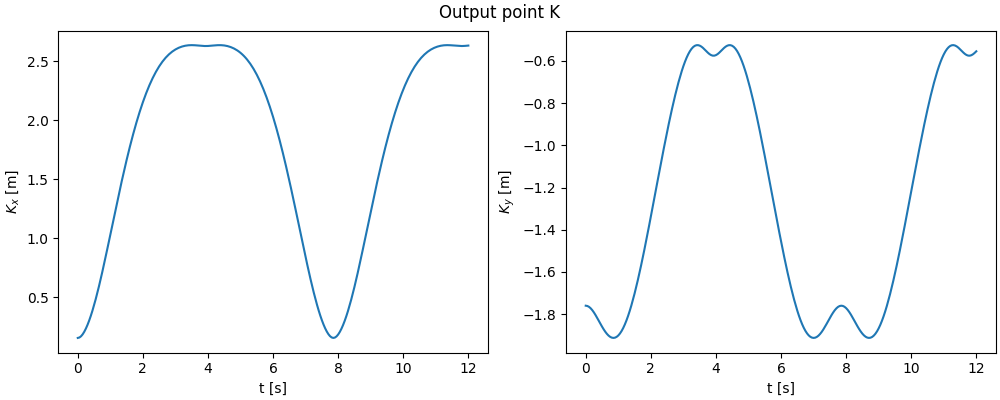

In [18]:
Kx = np.zeros_like(t)
Ky = np.zeros_like(t)

for k in range(len(t)):
    C = np.array([0.0, 0.0])
    AB = C + np.array([0.0, -s[k]])
    D = AB + rotate_vector(np.array([r3a, 0.0]), theta3[k])
    F = D  + rotate_vector(np.array([r5a, 0.0]), theta5[k])
    I = F  + rotate_vector(np.array([r6, 0.0]),  theta6[k])
    J = I  + rotate_vector(np.array([r8a, 0.0]), theta8[k])
    K = J  + rotate_vector(np.array([r8b, 0.0]), theta8[k])

    Kx[k] = K[0]
    Ky[k] = K[1]

figK, axK = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(10, 4))
figK.suptitle("Output point K")

axK[0].plot(t, Kx)
axK[0].set_ylabel(r'$K_x$ [m]')
axK[0].set_xlabel('t [s]')

axK[1].plot(t, Ky)
axK[1].set_ylabel(r'$K_y$ [m]')
axK[1].set_xlabel('t [s]')

plt.show()